In [ ]:
# === ResNet-50 TRAINING (WINDOWS + JUPYTER) - FINAL CODE ===

import os
import random
import time
import cv2


import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# -----------------------------------------------
# REPRODUCIBILITY
# -----------------------------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [ ]:
# -----------------------------------------------
# CONFIG
# -----------------------------------------------
DATASET_DIR = r"/content/drive/MyDrive/Capstrone/CASIA-dataset"  # <-- update to your dataset folder

attack_ratio = 0.5
BATCH_SIZE = 16
EPOCHS = 25
LR = 1e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = "resnet50_best.pth"
NUM_WORKERS = 0  # safe for Windows + Jupyter
EARLY_STOPPING_PATIENCE = 6
GRAD_CLIP_NORM = 3.0

print("Using device:", DEVICE)


Using device: cpu


In [ ]:
# DATASET CLASS (FIXED & ROBUST)
class FingerprintDataset(Dataset):
    def __init__(self, samples, transform=None):
        """
        samples: list of tuples (img_path, label)
        label: 0 -> Real, 1 -> Reconstructed/Attack
        """
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def _apply_simulated_attack(self, image):
        """Simulate realistic attack artifacts on a grayscale image (numpy 2D)."""

        # blur
        blur_val = int(np.random.choice([3, 5, 7]))
        sigma = float(np.random.uniform(0.3, 2.5))
        attacked = cv2.GaussianBlur(image, (blur_val, blur_val), sigmaX=sigma)

        # contrast / brightness
        alpha = float(np.random.uniform(0.6, 1.3))
        beta = int(np.random.randint(-25, 25))
        attacked = attacked.astype(np.float32) * alpha + beta

        # noise sometimes
        if np.random.rand() > 0.35:
            noise_sigma = float(np.random.uniform(3.0, 18.0))
            noise = np.random.normal(0, noise_sigma, attacked.shape).astype(np.float32)
            attacked = attacked + noise

        # occasional JPEG artifacts
        if np.random.rand() > 0.6:
            encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), int(np.random.uniform(30, 85))]
            _, encimg = cv2.imencode(
                '.jpg',
                np.clip(attacked, 0, 255).astype(np.uint8),
                encode_param
            )
            attacked = cv2.imdecode(encimg, cv2.IMREAD_GRAYSCALE).astype(np.float32)

        attacked = np.clip(attacked, 0, 255).astype(np.uint8)
        return attacked

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                raise IOError("Failed to load image (cv2.imread returned None)")

            # resize to model input size
            image = cv2.resize(image, (224, 224))

            # if marked as attack, simulate attack
            if label == 1:
                image = self._apply_simulated_attack(image)

            # convert grayscale -> RGB (3 channels)
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

            if self.transform is not None:
                image = self.transform(image)

            return image, torch.tensor(label, dtype=torch.long)

        except Exception as e:
            # fallback dummy item (keeps DataLoader stable)
            print(f"[Warning] Error loading {img_path}: {e}")
            return torch.randn(3, 224, 224), torch.tensor(0, dtype=torch.long)

In [ ]:
# TRANSFORMS

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomPerspective(distortion_scale=0.25, p=0.5),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])




In [ ]:
all_real_images = []

if not os.path.isdir(DATASET_DIR):
    raise FileNotFoundError(f"DATASET_DIR not found: {DATASET_DIR}")

for subject in sorted(os.listdir(DATASET_DIR)):
    subj_path = os.path.join(DATASET_DIR, subject)

    if not os.path.isdir(subj_path):
        continue

    for hand in os.listdir(subj_path):  # more flexible
        hand_path = os.path.join(subj_path, hand)

        if not os.path.isdir(hand_path):
            continue

        for img_name in os.listdir(hand_path):
            if img_name.lower().endswith(
                ('.bmp', '.png', '.jpg', '.jpeg', '.tif', '.tiff')
            ):
                all_real_images.append(os.path.join(hand_path, img_name))

print(f"Found {len(all_real_images)} real images.")

if len(all_real_images) < 10:
    raise RuntimeError("Dataset looks too small; check folder structure.")

random.shuffle(all_real_images)

split_idx = int(0.8 * len(all_real_images))
train_real_paths = all_real_images[:split_idx]

Found 1392 real images.


In [ ]:
test_real_paths = all_real_images[split_idx:]

# create samples: (path, label)
train_samples = [(p, 0) for p in train_real_paths]
test_samples  = [(p, 0) for p in test_real_paths]

num_train_attacks = int(len(train_real_paths) * attack_ratio)
num_test_attacks  = int(len(test_real_paths) * attack_ratio)

# sample without replacement where possible
if num_train_attacks <= len(train_real_paths):
    attack_sources_train = random.sample(train_real_paths, num_train_attacks)
else:
    attack_sources_train = [
        random.choice(train_real_paths) for _ in range(num_train_attacks)
    ]

if num_test_attacks <= len(test_real_paths):
    attack_sources_test = random.sample(test_real_paths, num_test_attacks)
else:
    attack_sources_test = [
        random.choice(test_real_paths) for _ in range(num_test_attacks)
    ]

# add attack samples (label = 1)
train_samples += [(p, 1) for p in attack_sources_train]
test_samples  += [(p, 1) for p in attack_sources_test]

# shuffle
random.shuffle(train_samples)
random.shuffle(test_samples)

# datasets
train_dataset = FingerprintDataset(train_samples, transform=train_transform)
test_dataset  = FingerprintDataset(test_samples, transform=test_transform)

# dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

Train size: 1669, Test size: 418


In [ ]:
# ------------------------------
# TRAINING LOOP (NO BREAK, logs early stopping)
# ------------------------------
best_val_loss = float("inf")

train_losses, val_losses = [], []
train_accs, val_accs = [], []

no_improve_epochs = 0
start_time = time.time()

# 🔹 store logs for replay
epoch_logs = []

for epoch in range(EPOCHS):
    epoch_start = time.time()
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    # ===================== TRAIN =====================
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for imgs, labels in tqdm(train_loader, desc="Training", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(params_to_optimize, GRAD_CLIP_NORM)
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    if running_total == 0:
        print("[Warning] No training samples processed this epoch.")
        continue

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ===================== VALIDATION =====================
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * imgs.size(0)

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    if val_total == 0:
        print("[Warning] No validation samples available.")
        break

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # ===================== SCHEDULER =====================
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    lr_msg = ""
    if new_lr != old_lr:
        lr_msg = f"LR reduced: {old_lr:.6f} -> {new_lr:.6f}"
        print(lr_msg)

    # ===================== CHECKPOINT & EARLY STOPPING =====================
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        status_msg = "Saved best checkpoint"
        print(status_msg)
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1
        status_msg = f"No improvement for {no_improve_epochs} epoch(s)."
        print(status_msg)

        # ✅ NO BREAK — only logging
        if no_improve_epochs >= EARLY_STOPPING_PATIENCE:
            es_msg = f"[Early stopping condition met ({EARLY_STOPPING_PATIENCE}), but continuing...]"
            print(es_msg)
            status_msg += " | " + es_msg

    # ===================== TIME =====================
    epoch_time = time.time() - epoch_start
    print(f"Epoch time: {epoch_time:.1f}s")

    # 🔹 Save log for replay
    epoch_logs.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lr_msg": lr_msg,
        "status_msg": status_msg,
        "time": epoch_time
    })


# ===================== FINAL SUMMARY =====================
total_time = time.time() - start_time

print("\n===== TRAINING COMPLETE =====")
print(f"Training finished in {total_time/60:.2f} minutes")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Total Epochs Completed: {len(epoch_logs)}")  # ✅ safer than EPOCHS


# =========================================================
# 🔁 WHILE LOOP: REPRINT ALL OUTPUTS
# =========================================================
print("\n===== REPLAYING TRAINING LOGS (WHILE LOOP) =====")

i = 0
while i < len(epoch_logs):
    log = epoch_logs[i]

    print(f"\n===== Epoch {log['epoch']}/{EPOCHS} =====")
    print(f"Train Loss: {log['train_loss']:.4f} | Train Acc: {log['train_acc']:.4f}")
    print(f"Val Loss: {log['val_loss']:.4f} | Val Acc: {log['val_acc']:.4f}")

    if log["lr_msg"]:
        print(log["lr_msg"])

    print(log["status_msg"])
    print(f"Epoch time: {log['time']:.1f}s")

    i += 1

print("\n===== REPLAY COMPLETE =====")



===== Epoch 1/25 =====


Train Loss: 0.3761 | Train Acc: 0.8892
Val Loss: 0.2372 | Val Acc: 0.9833
Saved best checkpoint
Epoch time: 1796.7s

===== Epoch 2/25 =====


Train Loss: 0.2800 | Train Acc: 0.9635
Val Loss: 0.2355 | Val Acc: 0.9761
Saved best checkpoint
Epoch time: 1001.6s

===== Epoch 3/25 =====


Train Loss: 0.2601 | Train Acc: 0.9688
Val Loss: 0.2352 | Val Acc: 0.9833
Saved best checkpoint
Epoch time: 1020.5s

===== Epoch 4/25 =====


Train Loss: 0.2602 | Train Acc: 0.9706
Val Loss: 0.2145 | Val Acc: 0.9928
Saved best checkpoint
Epoch time: 1000.2s

===== Epoch 5/25 =====


...

Train Loss: 0.2273 | Train Acc: 0.9880
Val Loss: 0.2131 | Val Acc: 0.9928
No improvement for 4 epoch(s).
Epoch time: 1007.5s

===== Epoch 22/25 =====


Train Loss: 0.2223 | Train Acc: 0.9904
Val Loss: 0.2266 | Val Acc: 0.9880
No improvement for 5 epoch(s).
Epoch time: 1005.1s

===== Epoch 23/25 =====


Train Loss: 0.2248 | Train Acc: 0.9898
Val Loss: 0.2057 | Val Acc: 0.9976
Saved best checkpoint
Epoch time: 1007.7s

===== Epoch 24/25 =====


Train Loss: 0.2291 | Train Acc: 0.9898
Val Loss: 0.2272 | Val Acc: 0.9856
No improvement for 1 epoch(s).
Epoch time: 1005.7s

===== Epoch 25/25 =====


Train Loss: 0.2270 | Train Acc: 0.9868
Val Loss: 0.2151 | Val Acc: 0.9928
No improvement for 2 epoch(s).
Epoch time: 1028.3s

===== TRAINING COMPLETE =====
Training finished in 433.01 minutes
Best Validation Loss: 0.2057
Total Epochs Completed: 25

===== REPLAYING TRAINING LOGS (WHILE LOOP) =====

===== Epoch 1/25 =====
Train Loss: 0.3761 | Train Acc: 0.8892
Val Loss: 0.2372 | Val Acc: 0.9833
Saved best checkpoint
Epoch time: 1796.7s

===== Epoch 2/25 =====
Train Loss: 0.2800 | Train Acc: 0.9635
Val Loss: 0.2355 | Val Acc: 0.9761
Saved best checkpoint
Epoch time: 1001.6s

===== Epoch 3/25 =====
Train Loss: 0.2601 | Train Acc: 0.9688
Val Loss: 0.2352 | Val Acc: 0.9833
Saved best checkpoint
Epoch time: 1020.5s

===== Epoch 4/25 =====
Train Loss: 0.2602 | Train Acc: 0.9706
Val Loss: 0.2145 | Val Acc: 0.9928
Saved best checkpoint
Epoch time: 1000.2s

===== Epoch 5/25 =====
Train Loss: 0.2533 | Train Acc: 0.9778
Val Loss: 0.2288 | Val Acc: 0.9880
No improvement for 1 epoch(s).
Epoch time: 1

Evaluating: 100%|██████████| 27/27 [01:32<00:00,  3.41s/it]



Classification Report:
               precision    recall  f1-score   support

         Real       1.00      1.00      1.00       279
Reconstructed       0.99      0.99      0.99       139

     accuracy                           1.00       418
    macro avg       0.99      0.99      0.99       418
 weighted avg       1.00      1.00      1.00       418



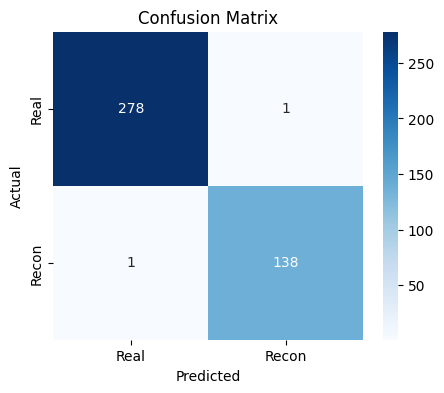

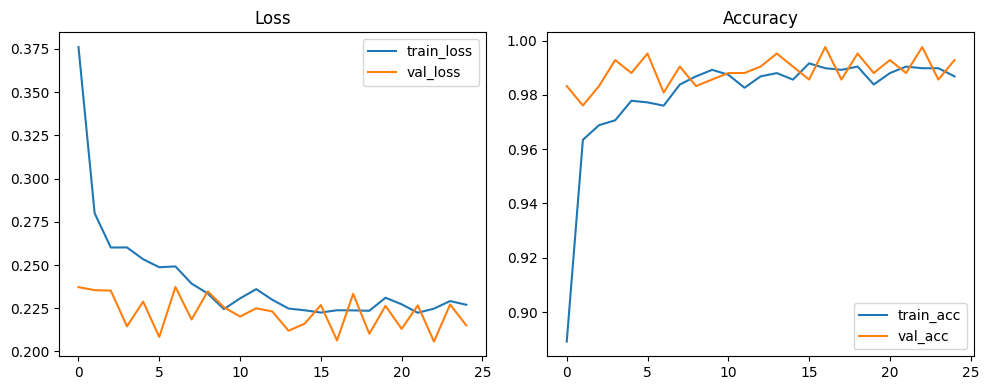

In [ ]:
# EVALUATION

# Load best model (if saved)
if os.path.exists(CHECKPOINT_PATH):
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        # Ensure CPU numpy arrays
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Reconstructed"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d',
    xticklabels=["Real", "Recon"],
    yticklabels=["Real", "Recon"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot training curves
plt.figure(figsize=(10, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.title('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='train_acc')
plt.plot(val_accs, label='val_acc')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()